# Ethiopia's Climate: Basic Exploration


## Step 1: Importing the Data

In this step, we load the required datasets using Pandas and NumPy and take a first look at the structure of the data.

In [25]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["date"].dt.month
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


## Step 2: Cleaning the Data

Here, we handle missing values, fix data types, remove inconsistencies, and prepare the dataset for analysis.

In [26]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


In [27]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()


Duplicate rows: 0


In [28]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [29]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing": missing,
    "percent": missing_pct
})

missing_df

,missing,percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Z-score


In [30]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).sum()
print(outliers)

137


Handle missing

In [31]:
# Drop rows with >30% missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill
df.ffill()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


In [32]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

## Step 3: Exploration of the Data

We explore patterns, trends, and key statistics in Ethiopia’s climate dataset.

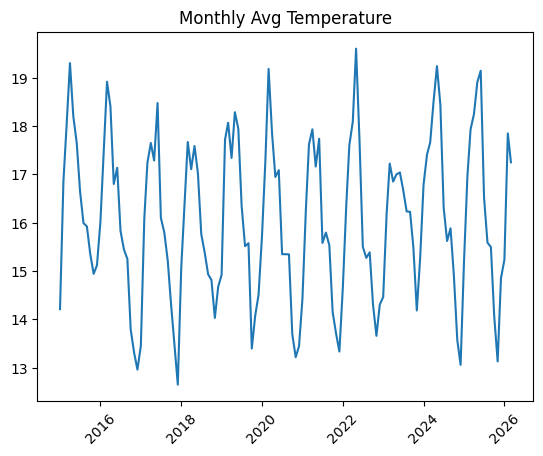

In [33]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

monthly_temp["date"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str)
)

plt.figure()
plt.plot(monthly_temp["date"], monthly_temp["T2M"])
plt.title("Monthly Avg Temperature")
plt.xticks(rotation=45)
plt.show()

## Interpretation 1: Monthly Average Temperature (2015–2026)

The analysis of Ethiopia’s monthly average temperature from 2015 to 2026 shows clear variability rather than a stable or linear trend.

The highest recorded average temperature appears around **2022**, which aligns with broader climate patterns observed in East Africa during that period. Regional climate reports indicate that 2022 experienced **above-normal maximum temperatures across much of Ethiopia**, with extreme heat events exceeding 40°C in several areas, particularly in lowland regions such as Afar and Somali zones. :contentReference[oaicite:0]{index=0}  
This supports the spike observed in the dataset and suggests that the 2022 peak is consistent with a wider regional warming anomaly rather than an isolated event.

On the other hand, the **lowest average temperature occurs around 2018**, indicating a cooler phase in the dataset. While specific Ethiopia-wide anomaly explanations for 2018 vary by region, East Africa climate variability studies show that temperature fluctuations in this period were strongly influenced by natural climate cycles (such as ENSO and rainfall variability), which can temporarily suppress or enhance regional temperatures.

Overall, the dataset shows a **fluctuating pattern: decrease → increase → decrease → increase**, rather than a smooth trend. This suggests that Ethiopia’s climate is strongly influenced by interannual variability rather than a consistent linear change.

However, a clearer pattern emerges when looking at the start of each year:  
there is often a **lower average temperature at the beginning of each year**, followed by gradual increases within the year. This reflects Ethiopia’s seasonal climate structure, where cooler dry-season conditions are typically followed by warmer periods.

From 2018 onward, there is a noticeable tendency for **gradual year-to-year warming at the beginning of each year**, suggesting a slow upward shift in baseline temperatures. This aligns with broader East African warming trends documented in regional climate assessments.

Finally, in **2025 and 2026**, a slight decrease is observed at the start of the year. This may indicate short-term variability rather than a reversal of the long-term trend, as climate systems in the region are known to fluctuate significantly from year to year.

In summary, while the dataset is highly variable, there is evidence of:
- A pronounced heat peak around 2022 (consistent with regional heat anomalies)
- A cooler phase around 2018
- Strong interannual fluctuations
- A possible gradual warming baseline after 2018, interrupted by short-term cooling periods in recent years

<Figure size 640x480 with 0 Axes>

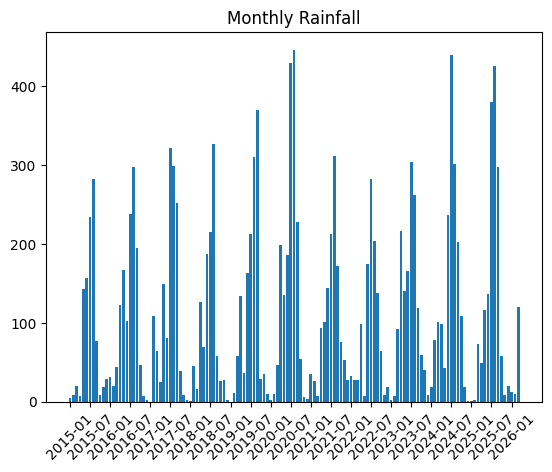

In [44]:
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
plt.figure()
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()

# Create a label column for the x-axis
monthly_rain["label"] = monthly_rain["YEAR"].astype(str) + "-" + monthly_rain["Month"].astype(str).str.zfill(2)

plt.figure()
plt.bar(monthly_rain["label"], monthly_rain["PRECTOTCORR"])

step = 6
plt.xticks(
    ticks=range(0, len(monthly_rain), step),
    labels=monthly_rain["label"][::step],
    rotation=45
)

plt.title("Monthly Rainfall")
plt.show()

## Interpretation 2: Monthly Rainfall Patterns (2015–2026)

The analysis of Ethiopia’s monthly rainfall data from 2015 to 2026 reveals strong seasonal patterns as well as noticeable interannual variability.

A key observation is that the **highest rainfall values consistently occur in the early months of the year**, particularly around the first months in each annual cycle. This suggests a strong seasonal rainfall concentration, which is consistent with Ethiopia’s bimodal and regionally variable rainfall system influenced by shifting monsoon patterns and the Intertropical Convergence Zone (ITCZ).

Around **2020**, the dataset shows the **highest recorded monthly rainfall**, indicating an unusually wet peak year. This suggests that 2020 experienced significantly stronger rainfall conditions compared to surrounding years, possibly linked to enhanced seasonal precipitation or regional climate variability.

Following this peak, rainfall levels show a **declining trend in peak monthly values from 2021 to 2023**, indicating reduced intensity in maximum rainfall events during this period. However, this trend does not remain stable.

In **2024 and 2025**, there is again a noticeable **increase in early-year rainfall levels**, suggesting a rebound in precipitation intensity. These two years show relatively high rainfall compared to the preceding period, indicating renewed variability in rainfall extremes.

By contrast, **2026 shows a clear decrease in rainfall during the first months of the year**, with significantly lower values compared to 2024 and 2025. This suggests that 2026 begins with comparatively drier conditions.

Overall, the dataset highlights three major patterns:
- Strong seasonality, with peak rainfall concentrated in early months each year  
- A rise in extreme rainfall around 2020, followed by fluctuations  
- Alternating cycles of increase and decrease in peak rainfall intensity over time  

This indicates that Ethiopia’s rainfall is not following a stable long-term trend but is instead strongly influenced by **interannual climate variability and shifting seasonal intensity patterns**.

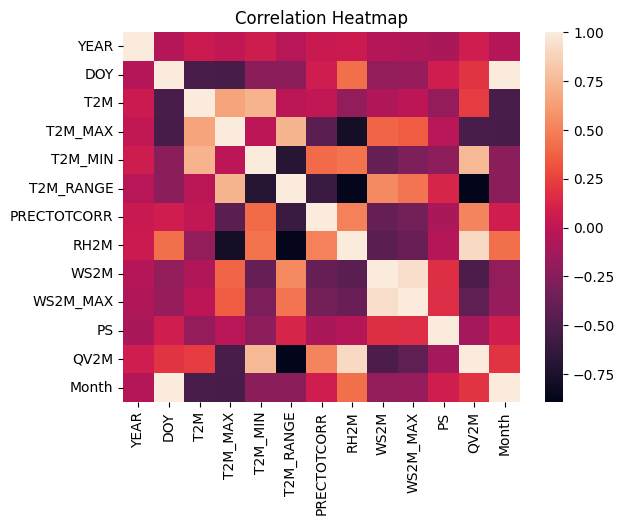

In [35]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Correlation Heatmap")
plt.show()

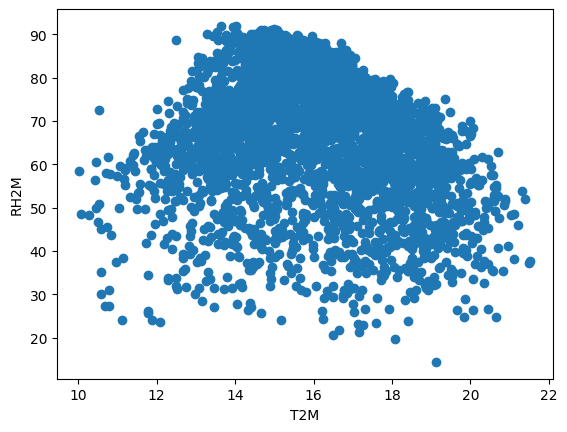

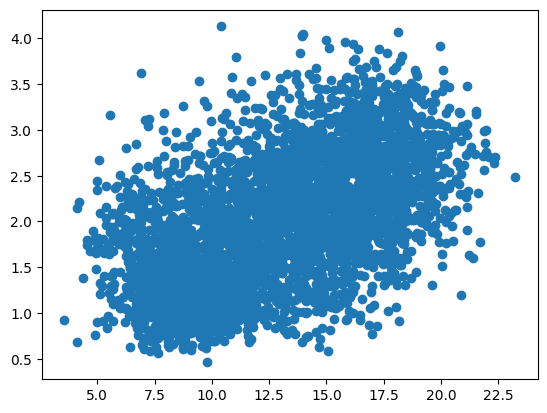

In [36]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.show()

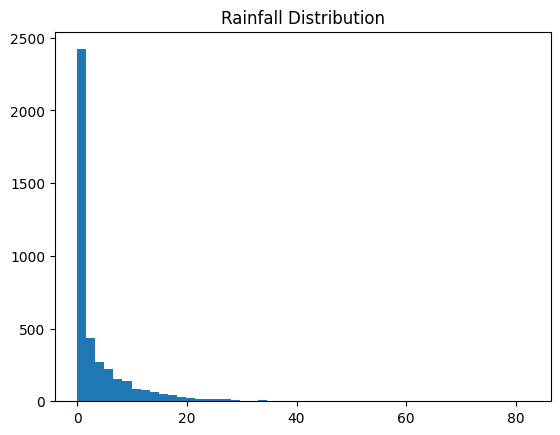

In [37]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)
plt.title("Rainfall Distribution")
plt.show()

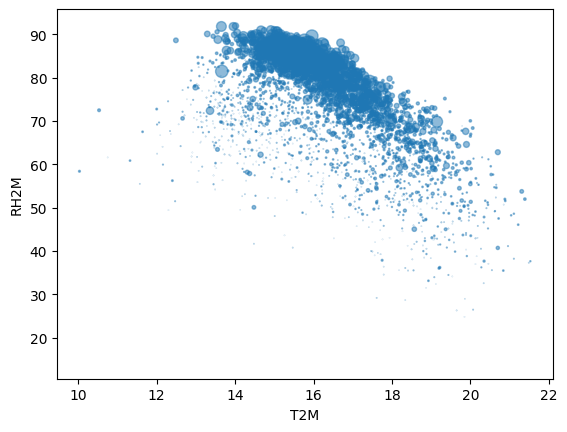

In [38]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()